In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import  joblib


In [2]:
df = pd.read_csv('data/customer_segmentation.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [5]:
df.isna().sum().sum()

np.int64(24)

In [6]:
df.dropna(inplace=True)

In [7]:
df.isna().sum().sum()

np.int64(0)

In [8]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [9]:
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [10]:
df['total_children'] = df['Kidhome'] + df['Teenhome']

In [11]:
df['age'] = 2026 - df['Year_Birth']

In [12]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'],dayfirst=True)

In [13]:
df['Dt_Customer'] 

0      2012-09-04
1      2014-03-08
2      2013-08-21
3      2014-02-10
4      2014-01-19
          ...    
2235   2013-06-13
2236   2014-06-10
2237   2014-01-25
2238   2014-01-24
2239   2012-10-15
Name: Dt_Customer, Length: 2216, dtype: datetime64[us]

In [14]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'total_children', 'age'],
      dtype='str')

In [15]:
total_spent = ['MntWines', 'MntFruits',
        'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
        'MntGoldProds']

df['total_spent'] = df[total_spent].sum(axis=1)

In [16]:
df['costomer_since'] = (pd.to_datetime('today') - df['Dt_Customer']).dt.days

In [17]:
df['costomer_since']

0       4981
1       4431
2       4630
3       4457
4       4479
        ... 
2235    4699
2236    4337
2237    4473
2238    4474
2239    4940
Name: costomer_since, Length: 2216, dtype: int64

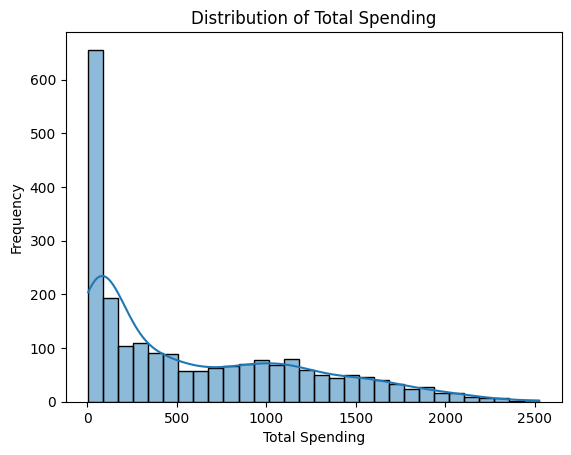

In [18]:
sns.histplot(df['total_spent'], bins=30, kde=True)
plt.title('Distribution of Total Spending')
plt.xlabel('Total Spending')
plt.ylabel('Frequency')
plt.show()

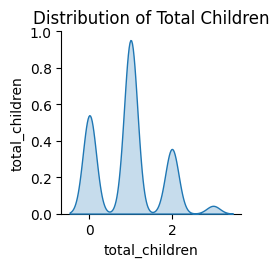

In [19]:
sns.pairplot(df[['total_children'] ], diag_kind='kde')
plt.title('Distribution of Total Children')
plt.xlabel('Total Children')
plt.ylabel('Frequency')
plt.show()  

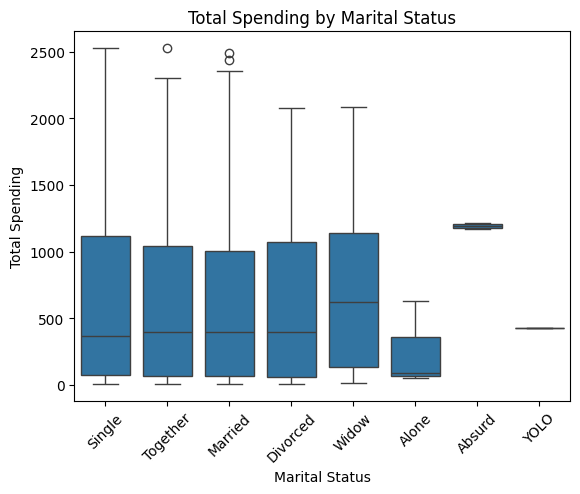

In [20]:
sns.boxplot(x='Marital_Status', y='total_spent', data=df)
plt.title('Total Spending by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Total Spending')
plt.xticks(rotation=45)
plt.show()

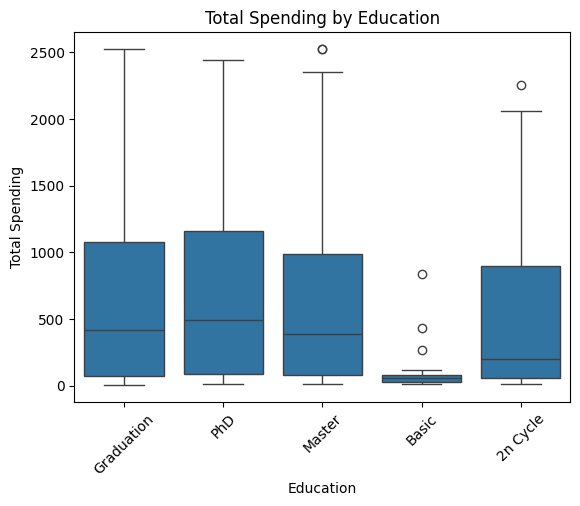

In [21]:
sns.boxplot(x='Education', y='total_spent', data=df)
plt.title('Total Spending by Education')
plt.xlabel('Education')
plt.ylabel('Total Spending')
plt.xticks(rotation=45)
plt.show()

In [22]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'total_children', 'age', 'total_spent', 'costomer_since'],
      dtype='str')

In [26]:
corr = df[['age', 'total_children', 'total_spent', 'Income',"NumWebPurchases", "NumStorePurchases","NumWebVisitsMonth"]]

In [27]:
corr

,age,total_children,total_spent,Income,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
0,69,0,1617,58138.0,8,4,7
1,72,2,27,46344.0,1,2,5
2,61,0,776,71613.0,8,10,4
3,42,1,53,26646.0,2,4,6
4,45,1,422,58293.0,5,6,5
...,...,...,...,...,...,...,...
2235,59,1,1341,61223.0,9,4,5
2236,80,3,444,64014.0,8,5,7
2237,45,0,1241,56981.0,2,13,6
2238,70,1,843,69245.0,6,10,3


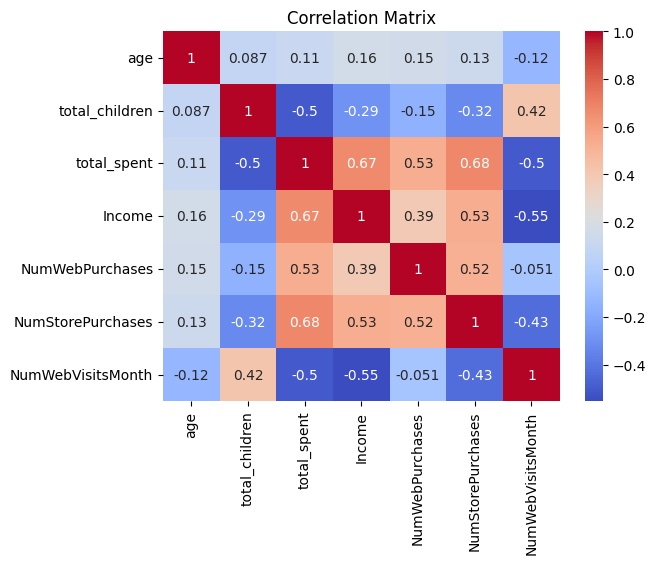

In [28]:
sns.heatmap(corr.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

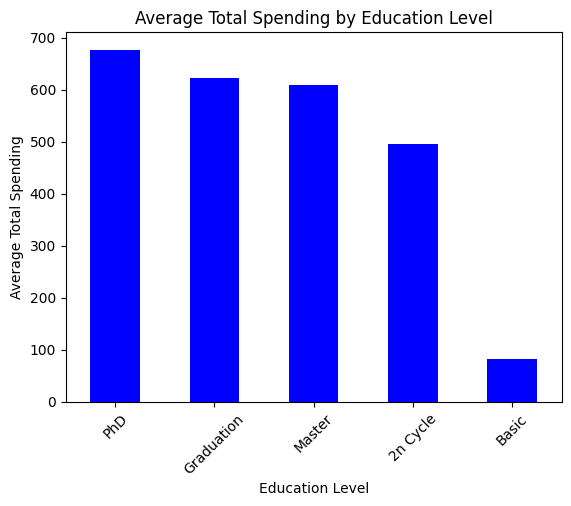

In [35]:
grob = df.groupby('Education')['total_spent'].mean().sort_values(ascending=False)
grob.plot(kind='bar', color='blue')
plt.title('Average Total Spending by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Total Spending')
plt.xticks(rotation=45)
plt.show()

In [36]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'total_children', 'age', 'total_spent', 'costomer_since'],
      dtype='str')

In [37]:
df['Acceptedany']= df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5','Response']].max(axis=1)

In [39]:
df['Acceptedany'].unique()

array([1, 0])

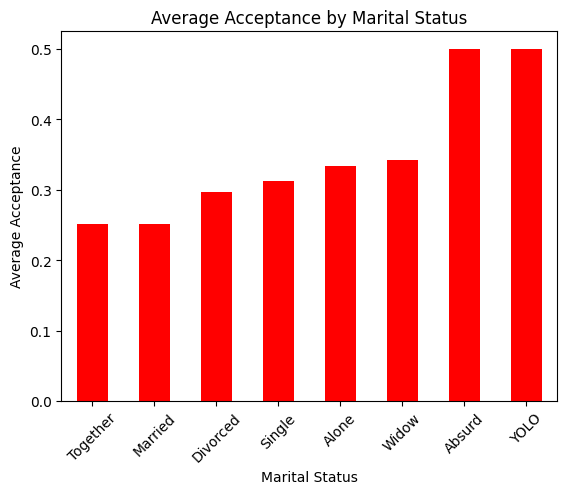

In [43]:
grop2 = df.groupby('Marital_Status')['Acceptedany'].mean().sort_values(ascending=True)
grop2.plot(kind='bar', color='red')
plt.title('Average Acceptance by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Average Acceptance')   
plt.xticks(rotation=45) 
plt.show()

In [45]:
bins = [0, 25, 35, 45, 55, 65, np.inf]
labels = ['0-25', '26-35', '36-45', '46-55', '56-65', '66+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
df['age_group']

0         66+
1         66+
2       56-65
3       36-45
4       46-55
        ...  
2235    56-65
2236      66+
2237    46-55
2238      66+
2239      66+
Name: age_group, Length: 2216, dtype: category
Categories (6, str): ['0-25' < '26-35' < '36-45' < '46-55' < '56-65' < '66+']

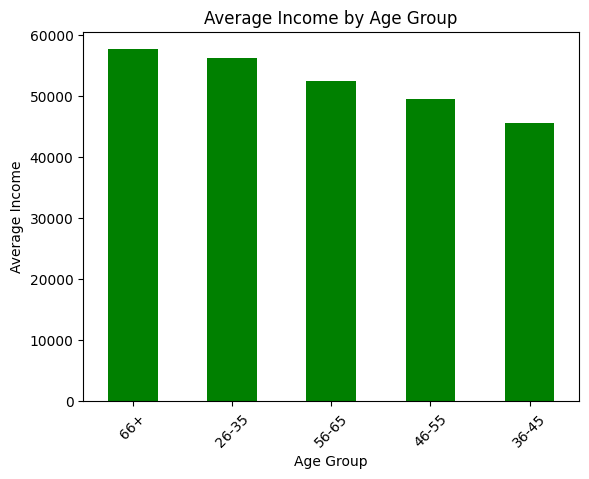

In [46]:
grop3 = df.groupby('age_group')['Income'].mean().sort_values(ascending=False)
grop3.plot(kind='bar', color='green')
plt.title('Average Income by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Income')
plt.xticks(rotation=45)
plt.show()

In [47]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'total_children', 'age', 'total_spent', 'costomer_since', 'Acceptedany',
       'age_group'],
      dtype='str')

In [51]:
features = ['age','Income','total_spent','NumWebPurchases', 'NumStorePurchases','NumWebVisitsMonth','Recency']

X = df[features].copy()
X

,age,Income,total_spent,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,69,58138.0,1617,8,4,7,58
1,72,46344.0,27,1,2,5,38
2,61,71613.0,776,8,10,4,26
3,42,26646.0,53,2,4,6,26
4,45,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,59,61223.0,1341,9,4,5,46
2236,80,64014.0,444,8,5,7,56
2237,45,56981.0,1241,2,13,6,91
2238,70,69245.0,843,6,10,3,8


In [53]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled


array([[ 0.98644293,  0.2340627 ,  1.67548812, ..., -0.55414289,
         0.69323197,  0.31053212],
       [ 1.23680074, -0.23455948, -0.96235832, ..., -1.16951781,
        -0.1315745 , -0.38050944],
       [ 0.31882209,  0.76947764,  0.28024985, ...,  1.29198186,
        -0.54397773, -0.79513438],
       ...,
       [-1.01641959,  0.18809052,  1.05169551, ...,  2.21504423,
         0.28082874,  1.4507507 ],
       [ 1.06989553,  0.67538765,  0.39140438, ...,  1.29198186,
        -0.95638097, -1.41707178],
       [ 1.23680074,  0.02470453, -0.7218    , ..., -0.55414289,
         0.69323197, -0.31140528]], shape=(2216, 7))

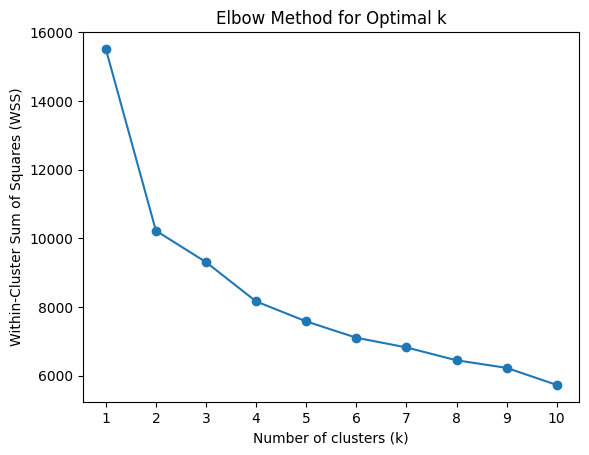

In [55]:
wss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wss.append(kmeans.inertia_)
    
plt.plot(range(1, 11), wss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WSS)')
plt.xticks(range(1, 11))
plt.show()

In [57]:
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)
df['cluster'].value_counts()

cluster
1    590
0    576
2    542
3    508
Name: count, dtype: int64

In [62]:
gro = df.groupby('cluster')[features].mean()

In [87]:
gro.T

cluster,0,1,2,3
age,53.241319,58.015254,56.749077,61.133858
Income,34393.715278,77137.727119,36715.747232,60153.415354
total_spent,117.152778,1270.849153,136.258303,893.988189
NumWebPurchases,2.184028,4.440678,2.416974,7.608268
NumStorePurchases,3.315972,8.428814,3.496310,8.025591
NumWebVisitsMonth,6.538194,2.432203,6.357934,6.181102
Recency,24.838542,51.676271,75.238007,45.348425


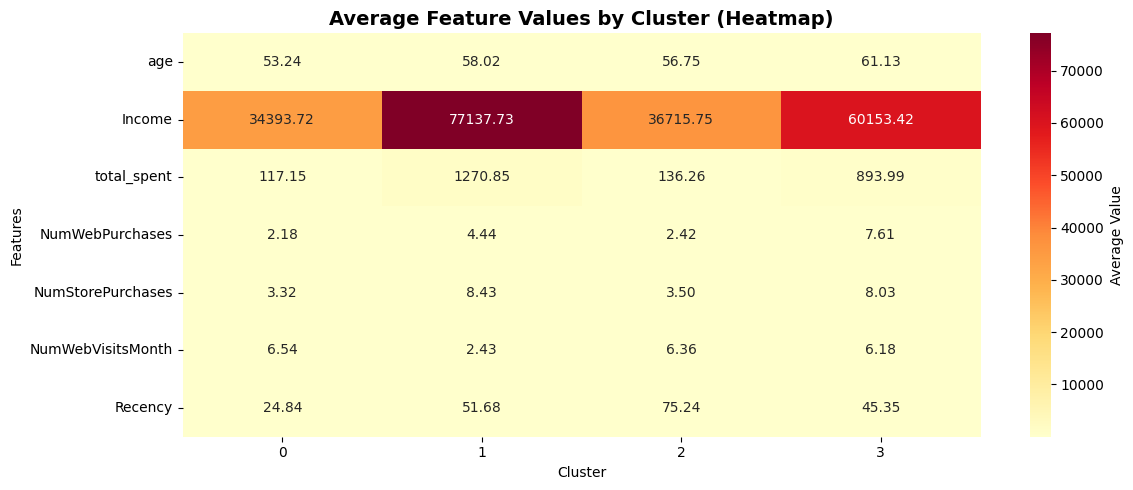

In [85]:
plt.figure(figsize=(12, 5))
sns.heatmap(gro.T, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Average Value'})
plt.title('Average Feature Values by Cluster (Heatmap)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Features')
plt.tight_layout()
plt.show()




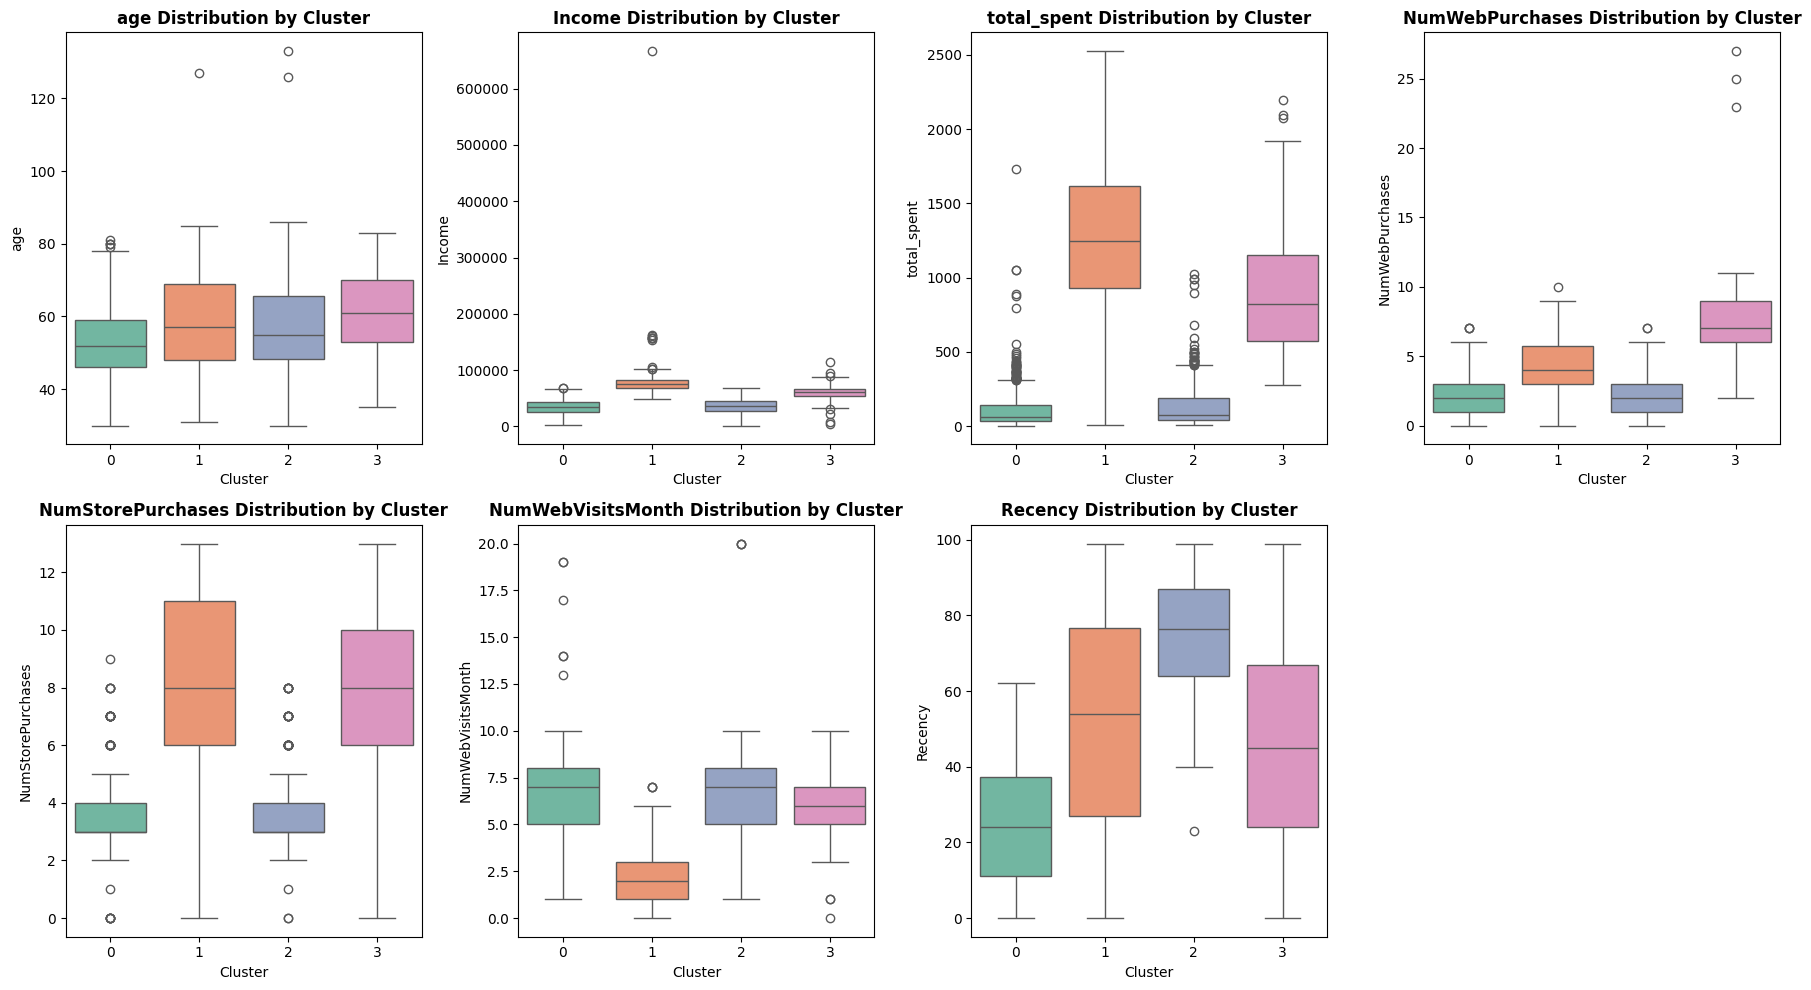

In [88]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(features):
    sns.boxplot(x='cluster', y=feature, data=df, ax=axes[idx], hue='cluster', palette='Set2', legend=False)
    axes[idx].set_title(f'{feature} Distribution by Cluster', fontweight='bold')
    axes[idx].set_xlabel('Cluster')

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()





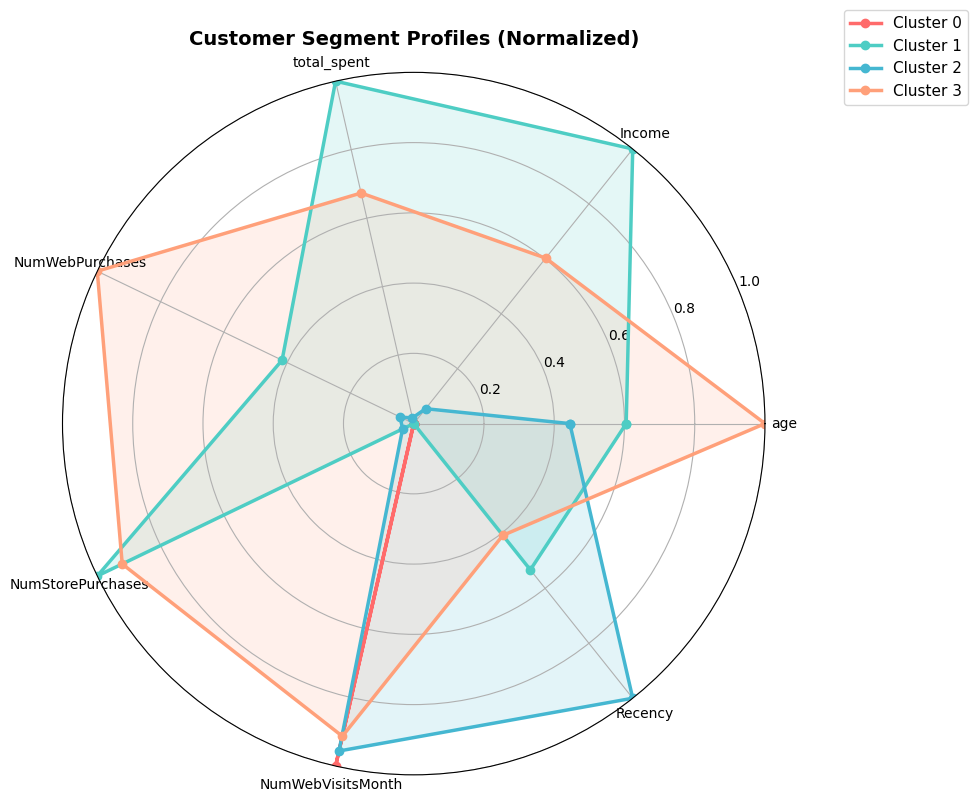

In [89]:
from math import pi

categories = features
angles = [n / len(categories) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

gro_normalized = (gro - gro.min()) / (gro.max() - gro.min())

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
for idx, cluster in enumerate(gro_normalized.index):
    values = gro_normalized.loc[cluster].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2.5, label=f'Cluster {cluster}', color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 1)
ax.set_title('Customer Segment Profiles (Normalized)', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True)
plt.tight_layout()
plt.show()


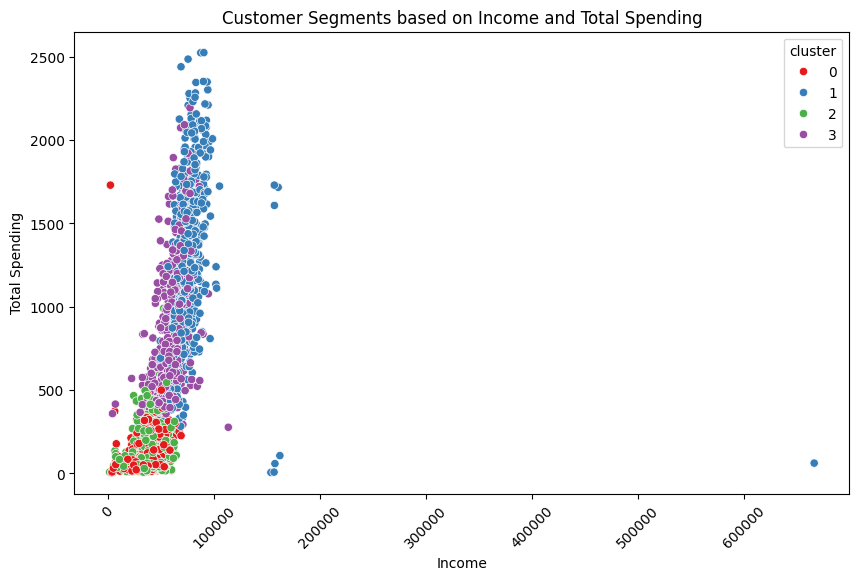

In [83]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Income', y='total_spent', hue='cluster', data=df, palette='Set1')
plt.title('Customer Segments based on Income and Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.xticks(rotation=45)
plt.show()

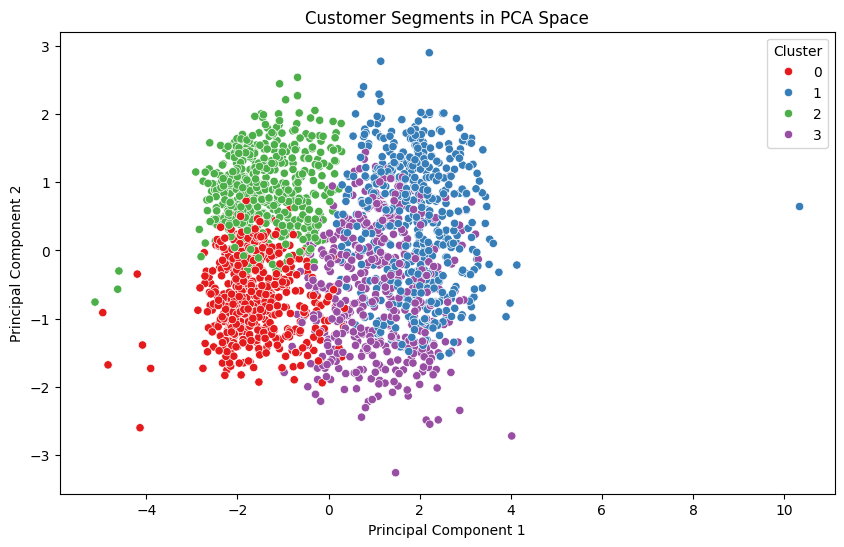

In [84]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled) 
df['pca1'] , df['pca2'] = X_pca[:, 0], X_pca[:, 1]
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pca1', y='pca2', hue='cluster', data=df, palette='Set1')
plt.title('Customer Segments in PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [94]:
joblib.dump(kmeans, 'customer_segmentation_kmeans_model.pkl')
joblib.dump(scaler, 'customer_segmentation_scaler.pkl')

['customer_segmentation_scaler.pkl']

In [95]:
joblib.dump(features, 'customer_segmentation_features.pkl')

['customer_segmentation_features.pkl']